# Taller 4 de radiacion en panel tipo honeycomb

**Objetivo.** Resolver el caso nominal por celda del panel compuesto, realizar un analisis de sensibilidad, seleccionar variables para el bono y entrenar un modelo de prediccion de la tasa de transferencia de calor.

**Nota.** Los textos explicativos y las celdas Markdown de este notebook fueron redactados con apoyo de Codex. La formulacion se corrigio para quedar consistente con el esquema de resistencias visto en clase y con la geometria del honeycomb usada en el taller.


In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from CoolProp.CoolProp import PropsSI
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

WORKSPACE_ROOT = Path.cwd().resolve()
if not (WORKSPACE_ROOT / 'datos').exists():
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
EES_COLUMN_NAMES = [
    'Tso_C',
    'Tsi_C',
    'L2_m',
    'q_W',
    'qpp_W_m2',
    'T0_C',
    'T1_C',
    'Tf_C',
    'Ra',
    'Nu',
    'h_conv_W_m2K',
    'h_rad_eff_W_m2K',
    'F12',
]
EES_DATASET_CANDIDATES = [
    WORKSPACE_ROOT / 'datos' / 'TABLE 1.CSV',
    WORKSPACE_ROOT / 'archive' / 'ees_exports' / 'Taller4_Radiacion_dataset.csv',
]

warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn.linear_model._base')


## 1. Datos del problema

El caso base del enunciado fija:

- $T_{s,i}=25$ degC
- $T_{s,o}=-10$ degC
- $\varepsilon=0.85$
- $W=10$ mm
- $t=2$ mm
- $L_1=L_3=12.5$ mm
- $L_2=50$ mm
- $k_1=0.0778$ W/mK
- $k_2=0.170$ W/mK
- aire atrapado a 1 atm

La apertura interna de la celda es $a=W-t=8$ mm.


In [2]:
BASE_PARAMS = {
    'Tsi_C': 25.0,
    'Tso_C': -10.0,
    'epsilon': 0.85,
    'W_m': 0.01,
    't_m': 0.002,
    'L1_m': 0.0125,
    'L2_m': 0.05,
    'L3_m': 0.0125,
    'k1': 0.0778,
    'k2': 0.170,
    'P_Pa': 101325.0,
    'g_m_s2': 9.81,
}

pd.DataFrame(
    {'Parametro': list(BASE_PARAMS.keys()), 'Valor': list(BASE_PARAMS.values())}
)


,Parametro,Valor
0,Tsi_C,25.000000
1,Tso_C,-10.000000
2,epsilon,0.850000
3,W_m,0.010000
4,t_m,0.002000
5,L1_m,0.012500
6,L2_m,0.050000
7,L3_m,0.012500
8,k1,0.077800
9,k2,0.170000


## 2. Hipotesis de modelado

1. Transferencia de calor unidimensional por celda.
2. Estado estacionario.
3. Las dos placas externas conducen calor con el area total $A=W^2$.
4. El nucleo honeycomb se modela como tres ramas en paralelo:
   - conduccion por las paredes solidas,
   - conveccion natural del aire en la cavidad,
   - radiacion entre las dos caras internas enfrentadas.
5. Las propiedades del aire se calculan a temperatura de pelicula
   $$T_f=\frac{T_0+T_1}{2}$$
   donde $T_0$ es la temperatura de la cara interna inferior de la cavidad y $T_1$ la de la cara interna superior.
6. Para conveccion natural se usa la correlacion tipo potencia que se trabajo en clase para recinto horizontal calentado por abajo, en la forma
   $$Nu = \max\left(1,\,0.069\,Ra^{1/3}\right)$$
7. Para radiacion se usa el factor de vision entre dos rectangulos paralelos finitos y la red radiativa de dos superficies grises difusas.


## 3. Desarrollo teorico y ecuaciones en LaTeX

La resistencia total por celda se modela como:

$$
R_{tot}=R_{in}+R_{core}+R_{out}
$$

con

$$
R_{in}=\frac{L_1}{k_1 W^2},
\qquad
R_{out}=\frac{L_3}{k_1 W^2}
$$

En el nucleo honeycomb, la rama conductiva por paredes usa el area solida:

$$
A_{wall}=W^2-(W-t)^2 = 2Wt-t^2
$$

por lo tanto:

$$
R_{wall}=\frac{L_2}{k_2 A_{wall}}
$$

La rama convectiva usa el area abierta de la cavidad:

$$
A_{open}=(W-t)^2
$$

El numero de Rayleigh se calcula con la altura de la cavidad:

$$
Ra = \frac{g\,\beta\,(T_0-T_1)L_2^3}{\nu\,\alpha}
$$

Luego:

$$
Nu = \max\left(1,\,0.069\,Ra^{1/3}\right),
\qquad
h_{conv}=\frac{Nu\,k_{air}}{L_2}
$$

$$
R_{conv}=\frac{1}{h_{conv}A_{open}}
$$

Para radiacion entre las dos caras internas enfrentadas se usa:

$$
\bar X = \frac{W-t}{L_2},
\qquad
\bar Y = \frac{W-t}{L_2}
$$

$$
F_{12}=\frac{2}{\pi\bar X\bar Y}\left[
\frac{1}{2}\ln\left(\frac{(1+\bar X^2)(1+\bar Y^2)}{1+\bar X^2+\bar Y^2}\right)
+ \bar X\sqrt{1+\bar Y^2}\tan^{-1}\left(\frac{\bar X}{\sqrt{1+\bar Y^2}}\right)
+ \bar Y\sqrt{1+\bar X^2}\tan^{-1}\left(\frac{\bar Y}{\sqrt{1+\bar X^2}}\right)
- \bar X\tan^{-1}(\bar X)-\bar Y\tan^{-1}(\bar Y)
\right]
$$

Como $A_1=A_2=A_{open}$ y $\varepsilon_1=\varepsilon_2=\varepsilon$:

$$
Q_{rad}=\frac{\sigma\left(T_0^4-T_1^4\right)}{\dfrac{1-\varepsilon}{A_{open}\varepsilon}+\dfrac{1}{A_{open}F_{12}}+\dfrac{1-\varepsilon}{A_{open}\varepsilon}}
$$

Se define una resistencia radiativa efectiva:

$$
R_{rad,eff}=\frac{T_0-T_1}{Q_{rad}}
$$

La resistencia equivalente del nucleo queda:

$$
\frac{1}{R_{core}}=\frac{1}{R_{wall}}+\frac{1}{R_{conv}}+\frac{1}{R_{rad,eff}}
$$

Finalmente:

$$
q=\frac{T_{s,i}-T_{s,o}}{R_{tot}}
$$

$$
T_0=T_{s,i}-qR_{in},
\qquad
T_1=T_{s,o}+qR_{out}
$$

Ese sistema se resuelve iterando implicitamente porque $R_{conv}$ y $R_{rad,eff}$ dependen de $T_0$ y $T_1$.


In [3]:
SIGMA = 5.670374419e-8


def view_factor_parallel_rectangles(a: float, b: float, L: float) -> float:
    x = a / L
    y = b / L
    term = (
        0.5 * math.log(((1.0 + x**2) * (1.0 + y**2)) / (1.0 + x**2 + y**2))
        + x * math.sqrt(1.0 + y**2) * math.atan(x / math.sqrt(1.0 + y**2))
        + y * math.sqrt(1.0 + x**2) * math.atan(y / math.sqrt(1.0 + x**2))
        - x * math.atan(x)
        - y * math.atan(y)
    )
    return 2.0 * term / (math.pi * x * y)


def air_properties(T_K: float, P_Pa: float = 101325.0) -> dict:
    rho = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Air')
    mu = PropsSI('V', 'T', T_K, 'P', P_Pa, 'Air')
    k = PropsSI('L', 'T', T_K, 'P', P_Pa, 'Air')
    cp = PropsSI('C', 'T', T_K, 'P', P_Pa, 'Air')
    beta = 1.0 / T_K
    nu = mu / rho
    alpha = k / (rho * cp)
    pr = nu / alpha
    return {
        'rho': rho,
        'mu': mu,
        'k': k,
        'cp': cp,
        'beta': beta,
        'nu': nu,
        'alpha': alpha,
        'Pr': pr,
    }


def solve_cell_case(params: dict, max_iter: int = 200, tol: float = 1e-9) -> dict:
    p = dict(BASE_PARAMS)
    p.update(params)

    A_total = p['W_m'] ** 2
    a_open = p['W_m'] - p['t_m']
    A_open = a_open ** 2
    A_wall = A_total - A_open

    R_in = p['L1_m'] / (p['k1'] * A_total)
    R_out = p['L3_m'] / (p['k1'] * A_total)
    R_wall = p['L2_m'] / (p['k2'] * A_wall)

    F12 = view_factor_parallel_rectangles(a_open, a_open, p['L2_m'])

    Tsi_K = p['Tsi_C'] + 273.15
    Tso_K = p['Tso_C'] + 273.15
    T0_K = Tsi_K - 5.0
    T1_K = Tso_K + 5.0

    for _ in range(max_iter):
        Tf_K = 0.5 * (T0_K + T1_K)
        air = air_properties(Tf_K, p['P_Pa'])
        delta_T = max(T0_K - T1_K, 1e-12)
        Ra = (
            p['g_m_s2']
            * air['beta']
            * delta_T
            * p['L2_m'] ** 3
            / (air['nu'] * air['alpha'])
        )
        Nu = max(1.0, 0.069 * Ra ** (1.0 / 3.0))
        h_conv = Nu * air['k'] / p['L2_m']
        R_conv = 1.0 / (h_conv * A_open)

        q_rad = SIGMA * (T0_K ** 4 - T1_K ** 4) / (
            (1.0 - p['epsilon']) / (A_open * p['epsilon'])
            + 1.0 / (A_open * F12)
            + (1.0 - p['epsilon']) / (A_open * p['epsilon'])
        )
        R_rad_eff = (T0_K - T1_K) / q_rad
        h_rad_eff = q_rad / (A_open * (T0_K - T1_K))

        R_core = 1.0 / (1.0 / R_wall + 1.0 / R_conv + 1.0 / R_rad_eff)
        q_W = (Tsi_K - Tso_K) / (R_in + R_core + R_out)

        T0_new = Tsi_K - q_W * R_in
        T1_new = Tso_K + q_W * R_out

        if max(abs(T0_new - T0_K), abs(T1_new - T1_K)) < tol:
            T0_K, T1_K = T0_new, T1_new
            break

        T0_K, T1_K = T0_new, T1_new

    q_cond = (T0_K - T1_K) / R_wall
    q_conv = (T0_K - T1_K) / R_conv

    return {
        **p,
        'A_total_m2': A_total,
        'A_open_m2': A_open,
        'A_wall_m2': A_wall,
        'F12': F12,
        'R_in_K_W': R_in,
        'R_out_K_W': R_out,
        'R_wall_K_W': R_wall,
        'R_conv_K_W': R_conv,
        'R_rad_eff_K_W': R_rad_eff,
        'R_core_K_W': R_core,
        'q_W': q_W,
        'qpp_W_m2': q_W / A_total,
        'Q_cond_W': q_cond,
        'Q_conv_W': q_conv,
        'Q_rad_W': q_rad,
        'T0_K': T0_K,
        'T1_K': T1_K,
        'Tf_K': 0.5 * (T0_K + T1_K),
        'T0_C': T0_K - 273.15,
        'T1_C': T1_K - 273.15,
        'Tf_C': 0.5 * (T0_K + T1_K) - 273.15,
        'Ra': Ra,
        'Nu': Nu,
        'h_conv_W_m2K': h_conv,
        'h_rad_eff_W_m2K': h_rad_eff,
    }


def run_sensitivity_study(grid: dict) -> pd.DataFrame:
    rows = []
    for parameter, values in grid.items():
        for value in values:
            params = dict(BASE_PARAMS)
            params[parameter] = float(value)
            result = solve_cell_case(params)
            result['parameter'] = parameter
            result['value'] = float(value)
            rows.append(result)
    return pd.DataFrame(rows)


def summarize_sensitivity(sensitivity_df: pd.DataFrame, q_ref: float) -> pd.DataFrame:
    rows = []
    for parameter in sensitivity_df['parameter'].unique():
        subset = sensitivity_df[sensitivity_df['parameter'] == parameter].copy()
        q_min = subset['q_W'].min()
        q_max = subset['q_W'].max()
        rows.append(
            {
                'parameter': parameter,
                'q_min_W': q_min,
                'q_max_W': q_max,
                'delta_q_W': q_max - q_min,
                'relative_delta_pct': 100.0 * (q_max - q_min) / q_ref,
            }
        )
    return pd.DataFrame(rows).sort_values('relative_delta_pct', ascending=False).reset_index(drop=True)


def generate_preliminary_dataset(n_samples: int, seed: int, feature_cols: list) -> pd.DataFrame:
    bounds = {
        'Tsi_C': (20.0, 35.0),
        'Tso_C': (-20.0, 5.0),
        'L2_m': (0.03, 0.07),
        'epsilon': (0.70, 0.95),
        't_m': (0.001, 0.003),
    }
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_samples):
        params = dict(BASE_PARAMS)
        for feature in feature_cols:
            low, high = bounds[feature]
            params[feature] = float(rng.uniform(low, high))
        rows.append(solve_cell_case(params))
    return pd.DataFrame(rows)


def resolve_ees_dataset_path() -> Path:
    for candidate in EES_DATASET_CANDIDATES:
        if candidate.exists():
            return candidate
    return EES_DATASET_CANDIDATES[0]


def load_ees_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=';', decimal=',', header=None)

    if df.shape[1] == 14:
        first_col = df.iloc[:, 0].astype(str)
        if first_col.str.contains('Run', case=False, na=False).any():
            df = df.iloc[:, 1:]

    if df.shape[1] != len(EES_COLUMN_NAMES):
        raise ValueError(
            f'El archivo {csv_path.name} no tiene 13 columnas utiles. Se detectaron {df.shape[1]} columnas.'
        )

    df.columns = EES_COLUMN_NAMES
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=['q_W']).reset_index(drop=True)
    return df


def train_and_compare_models(df: pd.DataFrame, feature_cols: list, target_col: str = 'q_W') -> dict:
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        'LinearRegression': Pipeline(
            [
                ('scale', StandardScaler()),
                ('model', LinearRegression()),
            ]
        ),
        'PolynomialDegree2': Pipeline(
            [
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('scale', StandardScaler()),
                ('model', LinearRegression()),
            ]
        ),
        'RandomForestRegressor': RandomForestRegressor(
            n_estimators=300, random_state=42
        ),
        'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    }

    metrics = []
    predictions = {}
    fitted_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae = mean_absolute_error(y_test, y_pred)
        metrics.append({'Modelo': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
        predictions[name] = pd.DataFrame(
            {'q_real_W': y_test.to_numpy(), 'q_pred_W': y_pred}, index=y_test.index
        )
        fitted_models[name] = model

    metrics_df = pd.DataFrame(metrics).sort_values(['RMSE', 'MAE']).reset_index(drop=True)
    best_name = metrics_df.iloc[0]['Modelo']

    return {
        'metrics': metrics_df,
        'predictions': predictions,
        'best_name': best_name,
        'best_predictions': predictions[best_name],
        'models': fitted_models,
        'feature_cols': feature_cols,
        'n_total': len(df),
        'n_train': len(X_train),
        'n_test': len(X_test),
    }


## 4. Solucion del caso nominal

Se resuelve primero el caso del enunciado para verificar consistencia fisica del modelo corregido.


In [4]:
nominal_result = solve_cell_case(BASE_PARAMS)
nominal_df = pd.DataFrame(
    {
        'Magnitud': [
            'q_W',
            'qpp_W_m2',
            'T0_C',
            'T1_C',
            'Tf_C',
            'F12',
            'Ra',
            'Nu',
            'h_conv_W_m2K',
            'h_rad_eff_W_m2K',
            'R_in_K_W',
            'R_core_K_W',
            'R_out_K_W',
        ],
        'Valor': [
            nominal_result['q_W'],
            nominal_result['qpp_W_m2'],
            nominal_result['T0_C'],
            nominal_result['T1_C'],
            nominal_result['Tf_C'],
            nominal_result['F12'],
            nominal_result['Ra'],
            nominal_result['Nu'],
            nominal_result['h_conv_W_m2K'],
            nominal_result['h_rad_eff_W_m2K'],
            nominal_result['R_in_K_W'],
            nominal_result['R_core_K_W'],
            nominal_result['R_out_K_W'],
        ],
    }
)

display(nominal_df)

assert BASE_PARAMS['Tso_C'] < nominal_result['T1_C'] < nominal_result['T0_C'] < BASE_PARAMS['Tsi_C']
assert nominal_result['q_W'] > 0.0


,Magnitud,Valor
0,q_W,0.005078
1,qpp_W_m2,50.778566
2,T0_C,16.841490
3,T1_C,-1.841490
4,Tf_C,7.500000
5,F12,0.008013
6,Ra,296443.046605
7,Nu,4.600759
8,h_conv_W_m2K,2.294122
9,h_rad_eff_W_m2K,0.040105


In [5]:
branch_df = pd.DataFrame(
    {
        'Rama': ['Conduccion en paredes', 'Conveccion natural', 'Radiacion'],
        'Q_rama_W': [
            nominal_result['Q_cond_W'],
            nominal_result['Q_conv_W'],
            nominal_result['Q_rad_W'],
        ],
        'R_rama_K_W': [
            nominal_result['R_wall_K_W'],
            nominal_result['R_conv_K_W'],
            nominal_result['R_rad_eff_K_W'],
        ],
    }
)
branch_df['Participacion_pct'] = 100.0 * branch_df['Q_rama_W'] / nominal_result['q_W']
display(branch_df)


,Rama,Q_rama_W,R_rama_K_W,Participacion_pct
0,Conduccion en paredes,0.002287,8169.934641,45.034685
1,Conveccion natural,0.002743,6810.884583,54.020947
2,Radiacion,0.000048,389604.967742,0.944368


Con esta interpretacion corregida, la rama radiativa se mantiene mucho mas resistiva que las ramas conductiva y convectiva. Por eso la emisividad termina siendo poco sensible en comparacion con $T_{s,o}$, $T_{s,i}$ o $L_2$.


## 5. Analisis de sensibilidad

Se barren cuatro parametros para decidir cuales conviene llevar al dataset del bono:

- $T_{s,i}$
- $T_{s,o}$
- $L_2$
- $\varepsilon$


In [6]:
sensitivity_grid = {
    'Tsi_C': np.linspace(20.0, 35.0, 30),
    'Tso_C': np.linspace(-20.0, 5.0, 30),
    'L2_m': np.linspace(0.03, 0.07, 30),
    'epsilon': np.linspace(0.70, 0.95, 30),
}

sensitivity_df = run_sensitivity_study(sensitivity_grid)
sensitivity_rank_df = summarize_sensitivity(sensitivity_df, nominal_result['q_W'])
display(sensitivity_rank_df)


,parameter,q_min_W,q_max_W,delta_q_W,relative_delta_pct
0,Tso_C,0.002751,0.006698,0.003946,77.711567
1,Tsi_C,0.004300,0.006656,0.002356,46.401129
2,L2_m,0.004726,0.005778,0.001052,20.720958
3,epsilon,0.005078,0.005078,0.000000,0.002788


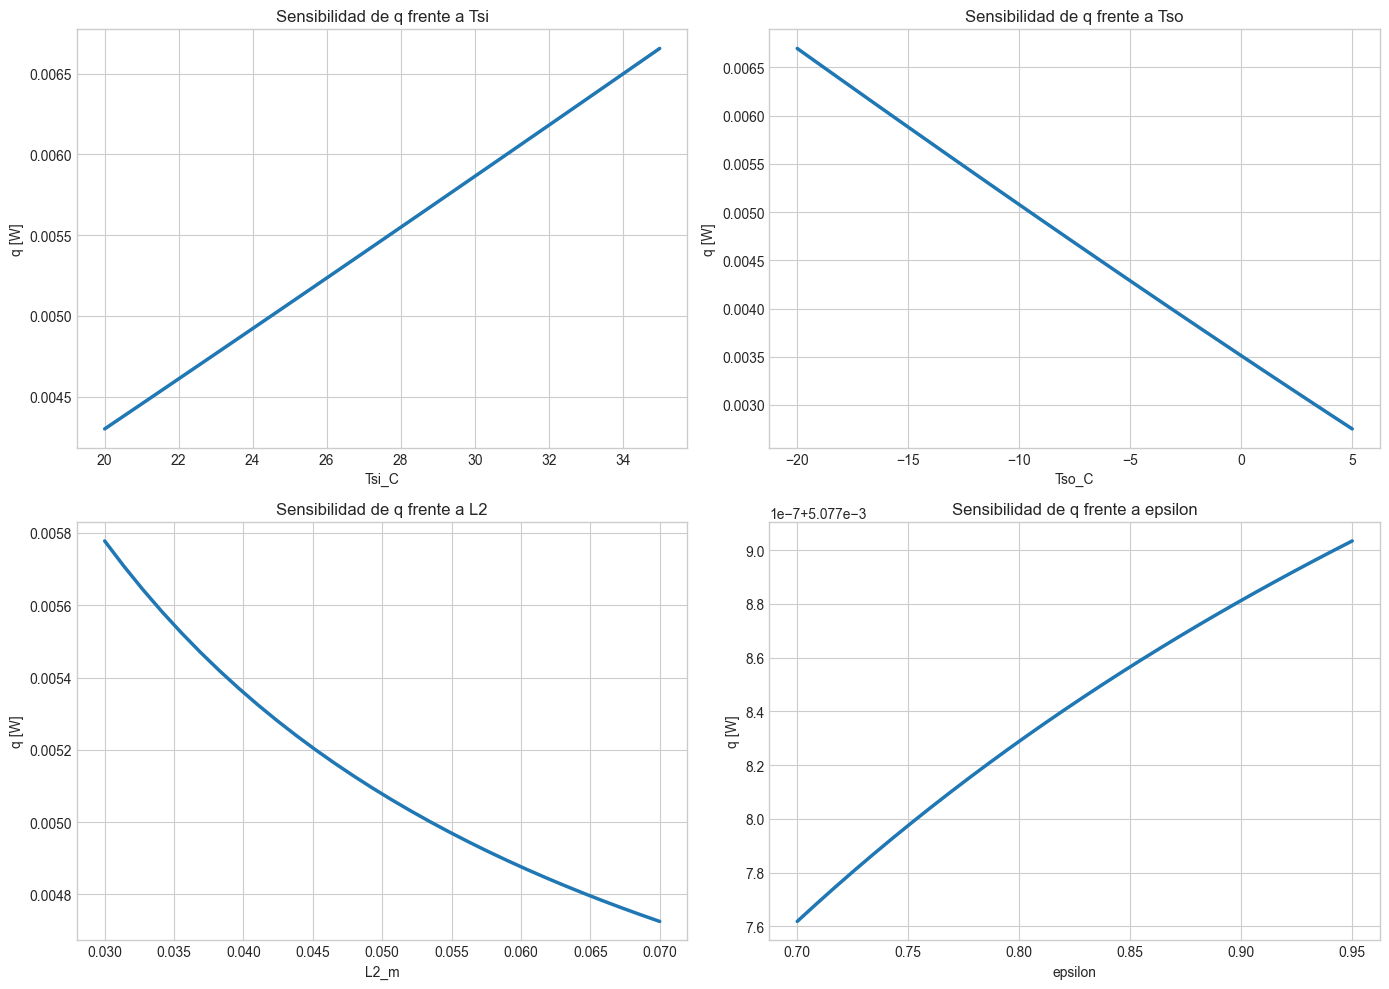

In [7]:
plot_titles = {
    'Tsi_C': 'Sensibilidad de q frente a Tsi',
    'Tso_C': 'Sensibilidad de q frente a Tso',
    'L2_m': 'Sensibilidad de q frente a L2',
    'epsilon': 'Sensibilidad de q frente a epsilon',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, parameter in zip(axes.flat, sensitivity_grid.keys()):
    subset = sensitivity_df[sensitivity_df['parameter'] == parameter].copy().sort_values('value')
    ax.plot(subset['value'], subset['q_W'], linewidth=2.5)
    ax.set_title(plot_titles[parameter])
    ax.set_xlabel(parameter)
    ax.set_ylabel('q [W]')
plt.tight_layout()
plt.show()


### Seleccion de variables para el bono

La estrategia adoptada aqui es:

1. barrer varios parametros,
2. medir el efecto de cada uno sobre $q$,
3. elegir las tres variables mas sensibles para construir el dataset del modelo de prediccion.


In [8]:
ML_FEATURES = sensitivity_rank_df['parameter'].head(3).tolist()
print('Variables seleccionadas para el dataset del bono:', ML_FEATURES)


Variables seleccionadas para el dataset del bono: ['Tso_C', 'Tsi_C', 'L2_m']


## 6. Dataset de EES y estructura usada en el bono

En esta version del bono se usa como fuente principal el archivo real exportado desde EES: `datos/TABLE 1.CSV`. Ese archivo no trae una fila de encabezados dentro del CSV; por eso la primera fila numerica tambien cuenta como observacion valida. En total, el conjunto cargado para el modelo contiene **100 observaciones**.

El dataset preliminar con CoolProp se conserva solo como respaldo, de modo que la tuberia del bono siga corriendo incluso si el CSV de EES no estuviera disponible.


In [9]:
preliminary_df = generate_preliminary_dataset(n_samples=1000, seed=42, feature_cols=ML_FEATURES)
print(f'Dataset preliminar de respaldo generado con CoolProp: {preliminary_df.shape[0]} filas')


Dataset preliminar de respaldo generado con CoolProp: 1000 filas


El archivo de EES se lee respetando el orden exacto de columnas observado en la exportacion:

1. `Tso_C`
2. `Tsi_C`
3. `L2_m`
4. `q_W`
5. `qpp_W_m2`
6. `T0_C`
7. `T1_C`
8. `Tf_C`
9. `Ra`
10. `Nu`
11. `h_conv_W_m2K`
12. `h_rad_eff_W_m2K`
13. `F12`

Nota: en la tabla de EES la decima columna puede verse como `ν` o con una tipografia parecida, pero para el notebook se interpreta como el numero de Nusselt `Nu`, coherente con sus valores numericos.


In [10]:
resolved_ees_path = resolve_ees_dataset_path()

if resolved_ees_path.exists():
    dataset_df = load_ees_dataset(resolved_ees_path)
    dataset_source = f'EES ({resolved_ees_path.name})'
else:
    dataset_df = preliminary_df.copy()
    dataset_source = 'Preliminar-CoolProp'

print(f'Fuente activa del dataset: {dataset_source}')
print(f'Observaciones cargadas: {len(dataset_df)}')
if dataset_source.startswith('EES'):
    print('La primera fila del CSV se trata como observacion, no como encabezado.')
else:
    print('No se encontro el CSV de EES. Se usa el dataset preliminar con la misma estructura.')

summary_cols = ML_FEATURES + ['q_W', 'Ra', 'Nu']
dataset_overview_df = dataset_df[summary_cols].agg(['min', 'max', 'mean']).T

display(dataset_df.head())
display(dataset_overview_df)


Fuente activa del dataset: EES (TABLE 1.CSV)
Observaciones cargadas: 100
La primera fila del CSV se trata como observacion, no como encabezado.


,Tso_C,Tsi_C,L2_m,q_W,qpp_W_m2,T0_C,T1_C,Tf_C,Ra,Nu,h_conv_W_m2K,h_rad_eff_W_m2K,F12
0,-6.320000,22.290000,0.041660,0.004247,42.470000,15.470000,0.503300,7.985000,139438.000000,3.578000,2.082000,0.057560,0.011460
1,-1.690000,33.820000,0.062100,0.004858,48.580000,26.010000,6.115000,16.070000,538779.000000,5.615000,2.246000,0.028650,0.005225
2,2.540000,23.330000,0.067100,0.002651,26.510000,19.070000,6.799000,12.940000,440794.000000,5.251000,1.926000,0.023780,0.004482
3,-4.630000,25.810000,0.033810,0.004797,47.970000,18.100000,3.077000,10.590000,71717.000000,2.867000,2.072000,0.088570,0.017190
4,-10.440000,26.820000,0.034720,0.005913,59.130000,17.320000,-0.939900,8.190000,98167.000000,3.183000,2.223000,0.082080,0.016330


,min,max,mean
Tso_C,-19.810000,4.990000,-7.503100
Tsi_C,20.070000,34.910000,27.497200
L2_m,0.030380,0.069880,0.050006
q_W,0.002453,0.008465,0.005114
Ra,40417.000000,1024000.000000,348077.020000
Nu,2.368000,6.955000,4.558540


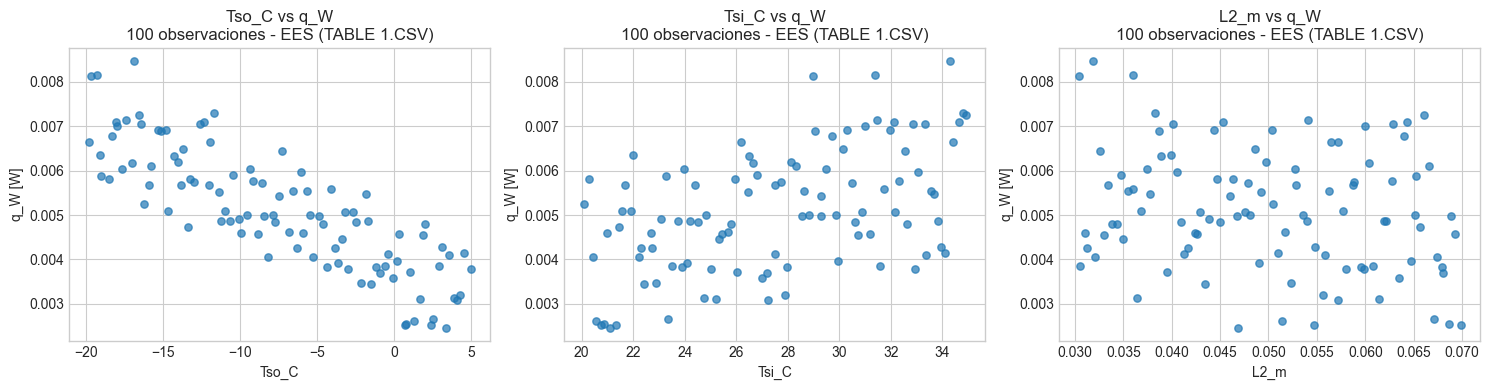

In [11]:
fig, axes = plt.subplots(1, len(ML_FEATURES), figsize=(5 * len(ML_FEATURES), 4))
if len(ML_FEATURES) == 1:
    axes = [axes]

for ax, feature in zip(axes, ML_FEATURES):
    ax.scatter(dataset_df[feature], dataset_df['q_W'], alpha=0.7, s=28)
    ax.set_xlabel(feature)
    ax.set_ylabel('q_W [W]')
    ax.set_title(f'{feature} vs q_W\n{len(dataset_df)} observaciones - {dataset_source}')

plt.tight_layout()
plt.show()


## 7. Bono de machine learning

El problema de prediccion sigue siendo de **regresion supervisada**, no de clasificacion. Sobre las 100 observaciones reales exportadas desde EES se comparan estos modelos:

- regresion lineal,
- regresion polinomial de grado 2,
- random forest,
- gradient boosting.

La particion se hace en formato `80/20`, es decir, `80` observaciones para entrenamiento y `20` para prueba.


In [12]:
ml_results = train_and_compare_models(dataset_df, ML_FEATURES)
display(ml_results['metrics'])
print(f"Observaciones totales: {ml_results['n_total']}")
print(f"Entrenamiento: {ml_results['n_train']} | Prueba: {ml_results['n_test']}")
print(f"Mejor modelo seleccionado: {ml_results['best_name']}")


,Modelo,R2,RMSE,MAE
0,PolynomialDegree2,0.999764,0.000020,0.000015
1,LinearRegression,0.997872,0.000059,0.000050
2,GradientBoostingRegressor,0.962037,0.000251,0.000185
3,RandomForestRegressor,0.926440,0.000350,0.000289


Observaciones totales: 100
Entrenamiento: 80 | Prueba: 20
Mejor modelo seleccionado: PolynomialDegree2


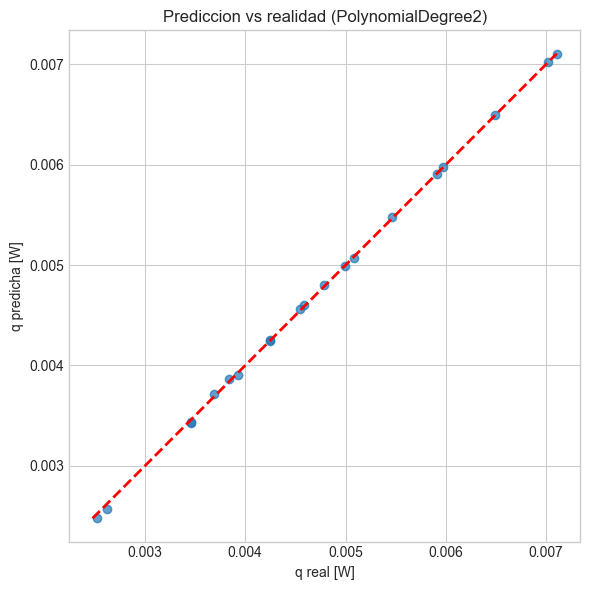

In [13]:
best_predictions = ml_results['best_predictions'].copy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(best_predictions['q_real_W'], best_predictions['q_pred_W'], alpha=0.7)
line_min = min(best_predictions['q_real_W'].min(), best_predictions['q_pred_W'].min())
line_max = max(best_predictions['q_real_W'].max(), best_predictions['q_pred_W'].max())
ax.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
ax.set_xlabel('q real [W]')
ax.set_ylabel('q predicha [W]')
ax.set_title(f"Prediccion vs realidad ({ml_results['best_name']})")
plt.tight_layout()
plt.show()


## 8. Lectura final del bono

Con el dataset real de EES, la seleccion de variables se mantiene coherente con el analisis de sensibilidad: `Tso_C`, `Tsi_C` y `L2_m` son suficientes para capturar la mayor parte de la variacion del flujo de calor `q_W` dentro del rango estudiado.

El bono no se planteo como regresion logistica ni como ajuste de una sola variable. Se uso una **regresion supervisada multivariable** entrenada con las 100 observaciones del modelo de EES, porque ese enfoque conserva el vinculo con la fisica y permite comparar directamente la prediccion contra el solver base.


## 9. Respuesta corta a la pregunta del bono

Los modelos de machine learning son utiles como sustitutos rapidos del modelo fisico cuando se necesita evaluar muchos casos del mismo rango paramatrico. En este taller, el mejor modelo se entrena con las 100 corridas de EES y luego reproduce `q_W` con error bajo dentro del dominio analizado.

Sin embargo, el modelo de ML no reemplaza el calculo de ingenieria: primero hay que construir un modelo termico correcto, validar tendencias fisicas y definir con cuidado el rango de entrenamiento. Fuera de ese rango, la referencia sigue siendo el modelo fisico en EES.
